In [22]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## Payoff Diagrams
1. long call: bet on stock going up
2. long put: bet on stock going down
3. short call: from the seller perspective bet on stock going down
4. short put: from the seller perspective bet on stock going up
5. Intrinsic Value: It is the amount our option is in the money.
6. Extrinsic Value: It is the premium amount minus the intrinsic value.

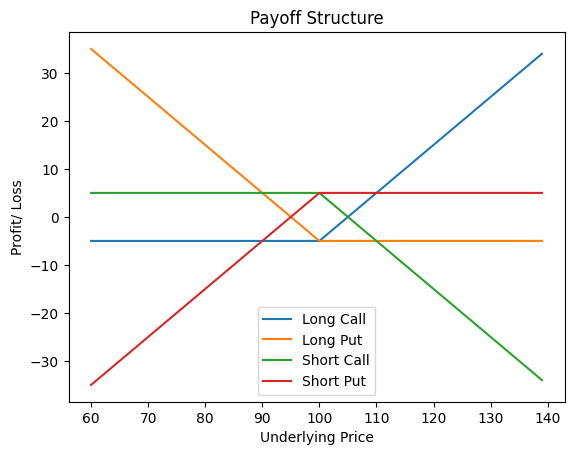

In [23]:
option = 5
strike = 100
underlying = np.arange(60,140)
long_call = np.where(underlying<strike, -option, underlying-strike-option)
long_put = np.where(underlying>strike, -option, strike-underlying-option)
short_call = np.where(underlying<strike, option, strike+option-underlying)
short_put = np.where(underlying>strike, option, underlying+option-strike)
plt.plot(underlying, long_call, label='Long Call')
plt.plot(underlying, long_put, label='Long Put')
plt.plot(underlying, short_call, label='Short Call')
plt.plot(underlying, short_put, label='Short Put')
plt.legend()
plt.xlabel('Underlying Price')
plt.ylabel('Profit/ Loss')
plt.title('Payoff Structure')
plt.show()

## Observations
1. Long call and short call are mirror images around x axis and long put and short put vice versa.
2. There is unlimited profit potential in long call and unlimited loss potential in short call. Profit is caped at strike - option for the long put and loss is also capped at the same value for short put.
3. Long put is a good mechanism to hedge long in the underlying. So it will act as an insurance.
4. If I want to buy a stock and we think it is over valued we can sell the put option and collect the premium. If the stock went up we get the premium and if the stock gets down we can buy it at the price we wanted it to buy.

## Option Greeks:
Delta: Measures how much the option price changes per $1 move in the underlying asset. Delta is 0.5 near at the money(strike price), 1 in the money and 0 out of the money.
Gamma: Measures the rate of change in Delta.
Near zero for deep in-the-money or out-of-the-money options.
Peaks at the strike price (at-the-money).
As expiration approaches, the peak gets sharper and taller, while the sides shrink.
Theta: Measures time decay. Option value drops daily as expiration approaches, hurting buyers and benefiting sellers.
Vega: Measures volatility sensitivity. Shows how much the option price changes per 1% change in implied volatility.

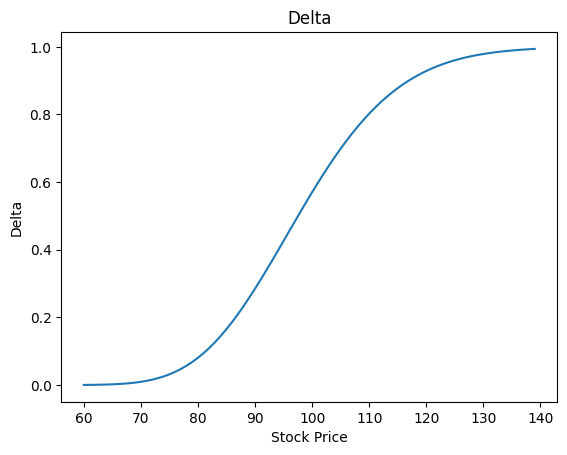

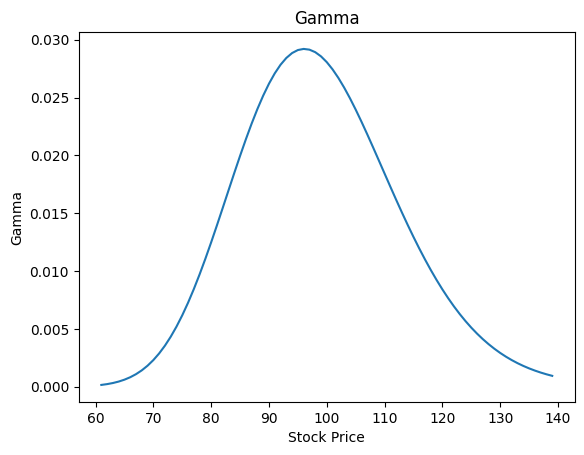

In [27]:
K = 100
S = np.arange(60,140)
iv = 0.20
t = 0.5
r = 0.03
d = (np.log(S/K) + (r + iv**2/2) * t)/(iv*t**0.5)
delta = norm.cdf(d)
plt.plot(S,delta)
plt.ylabel('Delta')
plt.xlabel('Stock Price')
plt.title('Delta')
plt.show()
gamma = np.diff(delta)
plt.plot(S[1:],gamma)
plt.ylabel('Gamma')
plt.xlabel('Stock Price')
plt.title('Gamma')
plt.show()

## Option Pricing:
6 Pricing Factors: Underlying price, strike price, time to expiration, risk-free rate, dividends, and implied volatility (IV).
The IV Signal: IV is the only factor back-calculated from market prices. It measures market fear and forward-looking uncertainty.
Core Trading Strategy: Buy options if you expect actual movement to exceed IV. Sell options if you expect less movement.
Volatility Smile: IV rises for deep in-the-money or out-of-the-money options, forming a smile shape.
Black-Scholes Flaw: The smile exists because Black-Scholes ignores market crashes. deep OTM put Traders price extreme risks higher to protect themselves. As the risk of a crash is higher than the black-sholes predict and therefore price of the put option increases and therefore the iv.


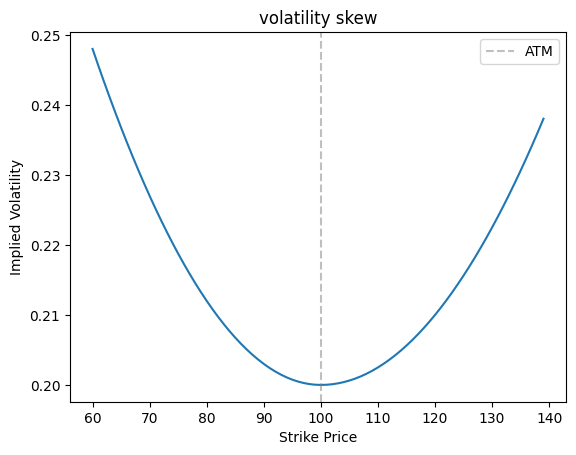

In [28]:
import numpy as np
strike = np.arange(60,140)
stock = 100
implied_volatility = np.where(strike>stock, 0.000025 * (strike - stock)**2 + 0.20,0.00003 * (strike - stock)**2 + 0.20)
plt.plot(strike, implied_volatility)
plt.title('volatility skew')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.axvline(x=100, linestyle='--', color='grey', alpha=0.5, label='ATM')
plt.legend()
plt.show()

## Observation:
Volatility Skew Notes
The difference in implied volatility (IV) between out-of-the-money (OTM) puts and OTM calls.
The Put Premium: IV is generally higher for OTM puts than for OTM calls.
Distribution Flaw: The Black-Scholes model assumes stock returns follow a normal distribution, which vastly underestimates the frequency of market crashes.
Real-World Risk: Because market crashes occur more often than predicted, sellers demand a higher premium to take on downside risk, driving up OTM put IV.